This notebook analyzes Telco customer churn using a structured data-science workflow: data loading, cleaning, exploratory analysis, feature engineering, model training, and evaluation. The objective is to understand the main churn drivers and build a model that can identify at-risk customers for retention actions.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

### Load the dataset

Read the dataset from the `data` folder and display the first rows to verify the file loaded correctly and to inspect column names and sample values.

In [2]:
df = pd.read_csv('../data/Telco_Customer_Churn.csv')


### Understanding the data set

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Observation: The first rows confirm that the dataset contains customer-level information such as service usage, billing details, and the churn label. The data looks structurally consistent, but `TotalCharges` appears to be stored as text in some rows and needs conversion before it can be used in numerical analysis.

Finding: The raw dataset is usable, but a preprocessing step is required to handle the non-numeric billing field correctly.

The dataset contains customer demographic details, subscribed telecom services, billing information, and a target variable named Churn, which indicates whether a customer has left the company.

In [4]:
df.shape

(7043, 21)

Dataset has 7043 records with 21 types of data for each customer

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

Dataset contains 21 data for a customer

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Observation: `df.info()` shows that `TotalCharges` has an object dtype while `MonthlyCharges` and `tenure` are numeric. This suggests that some values were recorded as strings rather than numbers.

Finding: `TotalCharges` must be converted to a numeric type and missing values handled before modeling. Otherwise, statistical summaries and machine-learning pipelines may behave incorrectly.

`df.info()` shows data types and non-null counts. We use it to find columns with wrong dtypes (e.g., numeric stored as strings) and to check for missing values.

Most variables are categorical, while SeniorCitizen, tenure, and MonthlyCharges are numeric. TotalCharges is stored as an object and requires further investigation might be chnage into number

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Observation: Summary shows `tenure` mean ≈ 32.37 and `MonthlyCharges` mean ≈ 64.76, with `tenure` ranging 0–72 months.

Finding: Distribution highlights many short-tenure customers and a wide spread in monthly charges; these are relevant for churn modeling.

The dataset contains 7,043 records with no missing values in these numerical columns. About 16.2% of customers are senior citizens. The average tenure is 32.37 months (range: 0–72 months), while the average MonthlyCharges is $64.76 (range: $18.25–$118.75).

In [8]:
df.describe(include="object")

/var/folders/p9/_62g3g211nl0rl1dvbxt61mh0000gn/T/ipykernel_46148/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


Observation: The categorical summary highlights the feature mix in the dataset. `customerID` is unique for each row, and the remaining categorical variables mostly have a small number of categories, which makes them suitable for label encoding or one-hot encoding.

Finding: `customerID` should be excluded from the model because it is just an identifier, while the categorical fields can provide useful churn signals when transformed appropriately.

The dataset has 7,043 customers. Most categorical features have 2–4 categories. Month-to-month is the most common contract type, while Electronic check is the most common payment method. 5,174 customers did not churn, compared with 1,869 customers who churned.

### Basic Data Cleaning

In [9]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Observation: `df.isna().sum()` initially reports zero NA because empty strings are not treated as `NaN`.

Finding: Need to further inspect string fields (e.g., `TotalCharges`) for empty values stored as `""`.

The dataset contains zero missing values. However, we can see that the column "TotalCharges" is of str type. We need to convert it to numeric type for analysis.

In [10]:
(df["TotalCharges"].str.strip() == "").sum()

np.int64(11)

Observation: 11 rows contain empty strings in `TotalCharges`, which is a common sign of data-entry inconsistency rather than a true missing-value issue.

Finding: Convert `TotalCharges` to numeric using `errors='coerce'` so blank values become `NaN`, then handle them using a strategy based on the training data to avoid leakage.

Total 11 row have empty value for TotalCharges

In [11]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

After conversion, the 11 invalid entries become `NaN` (visible in the next NA check).

The column is now numeric and ready for imputation.

Convert `TotalCharges` from string to numeric. `errors='coerce'` turns invalid or empty strings into `NaN` so we can handle missing numeric values explicitly.

convert str to number and if found "" string then convert into NA

In [12]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

As we have 11 TotalCharge value so we have fill these NA value to median value we will take care for this after spliting the data and before preproccessing 

In [13]:
df.duplicated().sum()

np.int64(0)

Zero fully duplicated rows.

No duplicate-removal required.

In [14]:
numerical_columns = df.select_dtypes(
    include=["int64","float64"]
).columns

categorical_columns = df.select_dtypes(
    include=["object"]
).columns

print(numerical_columns)
print(categorical_columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')


/var/folders/p9/_62g3g211nl0rl1dvbxt61mh0000gn/T/ipykernel_46148/2124853451.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


Observation: The target distribution shows 5,174 customers with `Churn = No` and 1,869 with `Churn = Yes`, which indicates a class imbalance in the dataset.

Finding: Since churn is the minority class, evaluation should emphasize metrics like precision, recall, and F1-score, and the train/test split should be stratified to preserve the class proportion.

The dataset has 4 numerical columns and 17 categorical columns

In [15]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Observation: Class counts — No: 5174, Yes: 1869.

Finding: ~26.5% churn rate indicates class imbalance; use stratified splits and metrics that account for imbalance (e.g., F1, recall).

The Dataset contains more no than yes for churn

In [16]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

Yes-> 26.5 % and No -> 73.5 % aprrox make this class imbalance

In [17]:
df= df.drop(columns=["customerID"])

Observation: `customerID` dropped.

Finding: Identifier removal prevents information leakage and reduces irrelevant features.

Need to drop drop customer ID as it has no use in model training and it doesn't tell about anything about churn

In [18]:
df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

Observation: The churn label has been mapped to binary values, making it compatible with scikit-learn classifiers.

Finding: This conversion is necessary for supervised classification, as the model expects numeric labels for training and evaluation.

Convert "Yes" to 1 and "No" to 0 as str to number 

In [19]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

After mapping yes to 1 and No to 0

Feature Engineering

Two features are created before the train/test split so they can be included in model training without data leakage:

- **TenureGroup:** Groups customers into New, Short-Term, Medium-Term, and Long-Term tenure categories. This helps capture non-linear churn patterns across customer lifecycle stages.
- **AverageMonthlyCharges:** Calculates TotalCharges divided by tenure. This provides an additional view of the customer's average monthly spending.


In [20]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["New", "Short-Term", "Medium-Term", "Long-Term"])

In [21]:
df["AverageMonthlyCharges"] = df["TotalCharges"] / df["tenure"].replace(0, np.nan)

In [22]:
x = df.drop(columns=["Churn"])

Created features dataframe `x` containing all columns except `Churn`. This keeps the target variable separate so the model can learn from customer attributes while preserving a clear train/test split.

The derived feature `AverageMonthlyCharges` is based on the billing history and helps capture the effective monthly spend pattern of each customer.

In [23]:
y = df["Churn"]

In [24]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,AverageMonthlyCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,New,29.850000
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,0,Medium-Term,55.573529
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,New,54.075000
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,Medium-Term,40.905556
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,New,75.825000


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   gender                 7043 non-null   str     
 1   SeniorCitizen          7043 non-null   int64   
 2   Partner                7043 non-null   str     
 3   Dependents             7043 non-null   str     
 4   tenure                 7043 non-null   int64   
 5   PhoneService           7043 non-null   str     
 6   MultipleLines          7043 non-null   str     
 7   InternetService        7043 non-null   str     
 8   OnlineSecurity         7043 non-null   str     
 9   OnlineBackup           7043 non-null   str     
 10  DeviceProtection       7043 non-null   str     
 11  TechSupport            7043 non-null   str     
 12  StreamingTV            7043 non-null   str     
 13  StreamingMovies        7043 non-null   str     
 14  Contract               7043 non-null   str     
 15

In [26]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   gender                 7043 non-null   str     
 1   SeniorCitizen          7043 non-null   int64   
 2   Partner                7043 non-null   str     
 3   Dependents             7043 non-null   str     
 4   tenure                 7043 non-null   int64   
 5   PhoneService           7043 non-null   str     
 6   MultipleLines          7043 non-null   str     
 7   InternetService        7043 non-null   str     
 8   OnlineSecurity         7043 non-null   str     
 9   OnlineBackup           7043 non-null   str     
 10  DeviceProtection       7043 non-null   str     
 11  TechSupport            7043 non-null   str     
 12  StreamingTV            7043 non-null   str     
 13  StreamingMovies        7043 non-null   str     
 14  Contract               7043 non-null   str     
 15

In [27]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.3, random_state = 42, stratify = y
)

Data was split into training and test sets with stratification to preserve the churn ratio in both subsets. This is important in an imbalanced classification problem because it ensures the model is evaluated on a representative sample of both classes.

This split helps reduce sampling bias and gives a more reliable estimate of out-of-sample performance.

In [28]:
train_median_tc = x_train["TotalCharges"].median()  # From training data only!
x_train["TotalCharges"] = x_train["TotalCharges"].fillna(train_median_tc)


train_median_amc = x_train["AverageMonthlyCharges"].median()  # From training data only!
x_train["TotalCharges"] = x_train["TotalCharges"].fillna(train_median_amc)


After the train/test split, the missing values in `TotalCharges` and the derived `AverageMonthlyCharges` were addressed using statistics computed from the training data only. This prevents information leakage from the test set and keeps the evaluation realistic.

The test set remains untouched for preprocessing statistics so that model performance reflects real generalization.

### Exploratory Data Analysis (EDA)

The objective of EDA is to understand customer characteristics and identify factors associated with customer churn.

Before plotting, we load visualization libraries and pipeline utilities. EDA plots help surface patterns, class imbalance, and features likely correlated with churn.

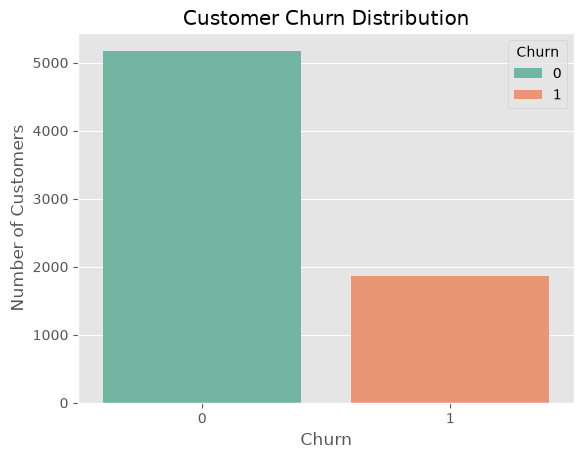

In [29]:
sns.countplot(
    data = df,
    x = "Churn",
    palette = "Set2",
    hue = "Churn",
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

Plot shows a larger bar for non-churn customers than for churners, confirming the dataset is imbalanced.

This visual supports the use of class-aware evaluation and highlights why accuracy alone is not a sufficient measure for churn prediction.

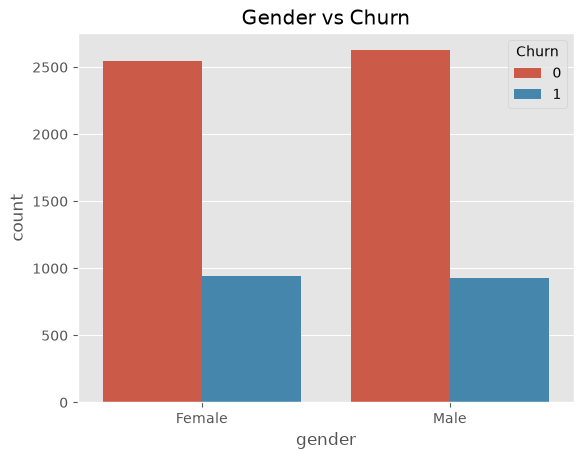

In [30]:
sns.countplot(
    data=df,
    x="gender",
    hue="Churn"
)

plt.title("Gender vs Churn")

plt.show()

The distribution of churn across gender categories is relatively similar, suggesting that gender is not a major driver of churn in this dataset.

This suggests that retention strategies should focus more on service usage, contract terms, billing behaviors, and tenure rather than demographic category alone.

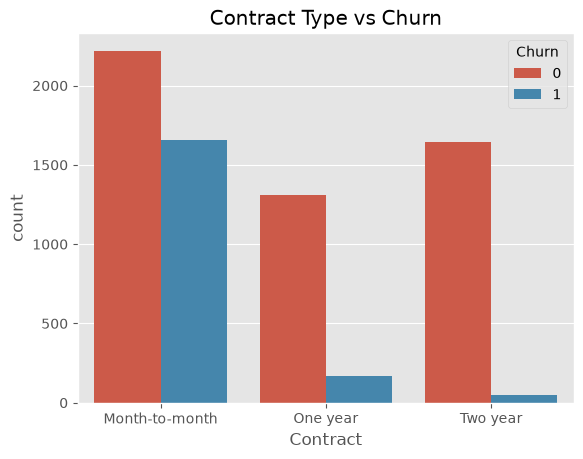

In [31]:
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract Type vs Churn")

plt.show()

Customers on month-to-month contracts show a noticeably higher churn rate than customers on one-year or two-year contracts.

This pattern suggests that contractual commitment is strongly related to churn risk. Customers without long-term commitments may be easier to retain through incentives, conservation offers, or contract upgrades.

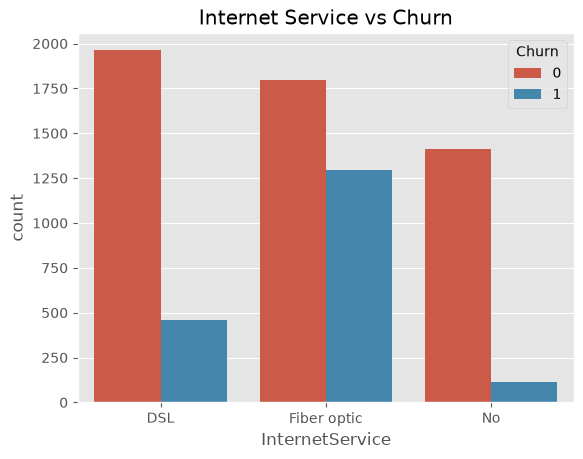

In [32]:
sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Internet Service vs Churn")

plt.show()

Churn rates differ across internet service types, with Fiber optic customers showing a comparatively higher churn rate.

This may indicate service quality, pricing, or product-fit issues associated with fiber-based plans. It is a useful signal for targeted retention analysis, but it should be interpreted as a relationship rather than proof of direct causation.

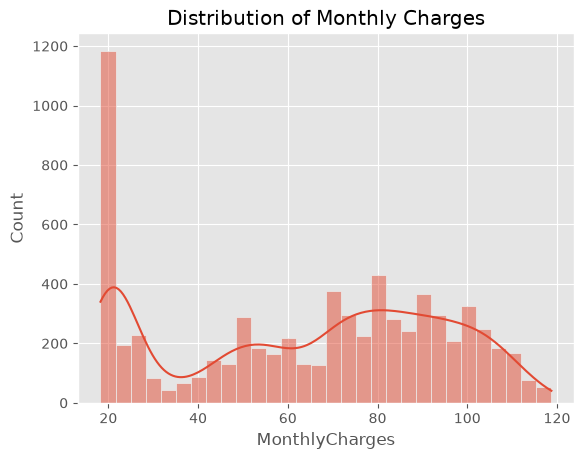

In [33]:
sns.histplot(
    data=df,
    x="MonthlyCharges",
    bins=30,
    kde=True
)

plt.title("Distribution of Monthly Charges")

plt.show()

Observation: The monthly charges distribution is right-skewed and spread across a wide range, with a visible concentration of customers paying moderate amounts.

Finding: This feature is likely relevant to churn prediction, especially because pricing often interacts with perceived value and service satisfaction. A transformation is not strictly required, but the distribution is useful to keep in mind during modeling.

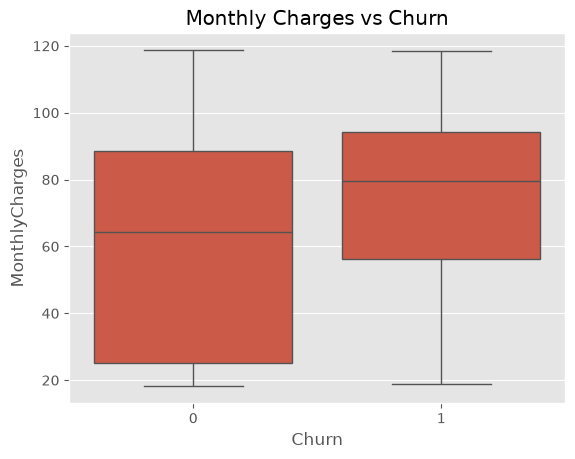

In [34]:

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")

plt.show()

Customers with higher monthly charges tend to show greater churn risk.

This pattern suggests that customers paying more for telecom services may be more sensitive to value-for-money issues, service quality, or competitor offers. It also means that monthly spend is useful for identifying higher-risk customers even before a formal churn event occurs.

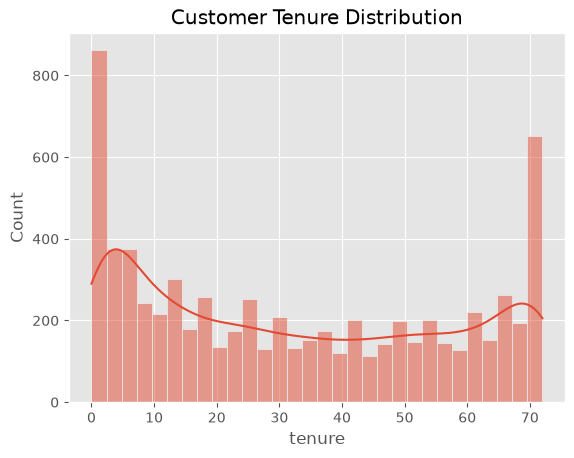

In [35]:

sns.histplot(
    data=df,
    x="tenure",
    bins=30,
    kde=True
)

plt.title("Customer Tenure Distribution")

plt.show()

Tenure distribution peaks at low values and declines for longer customer relationships.

This indicates that many customers are relatively new, while a smaller group remains with the provider for longer periods. Shorter tenure is commonly associated with higher churn risk, so this feature is likely to be an important predictor in the model.

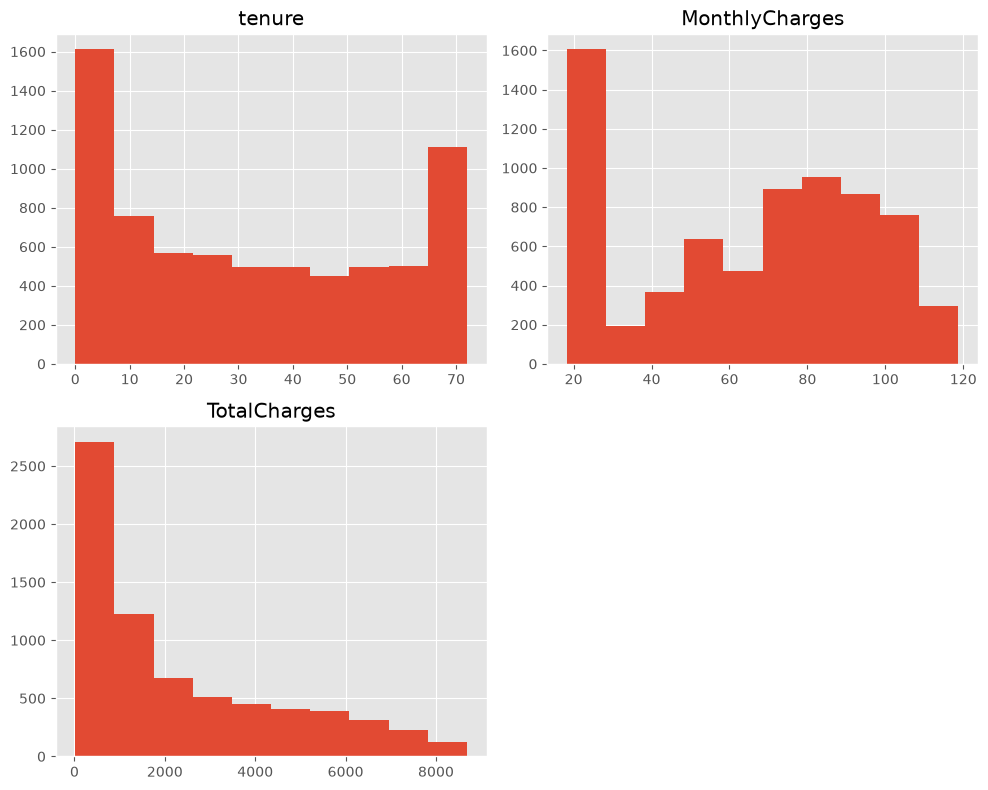

In [36]:
df[["tenure","MonthlyCharges","TotalCharges"]].hist(figsize=(10,8))
plt.tight_layout()
plt.show()


Tenure: Most customers have relatively short tenure, with fewer customers in the middle ranges and a noticeable group of long-term customers.
MonthlyCharges: Monthly charges are spread across a broad range, with more customers concentrated around lower-to-middle charges.
TotalCharges: Total charges are right-skewed, with many customers having lower total charges and fewer customers having higher charges.
Business Insight

Tenure and billing characteristics help understand customer behaviour and potential churn risk. Shorter-tenure customers may need stronger onboarding and retention strategies, while high-value customers may require targeted retention efforts.

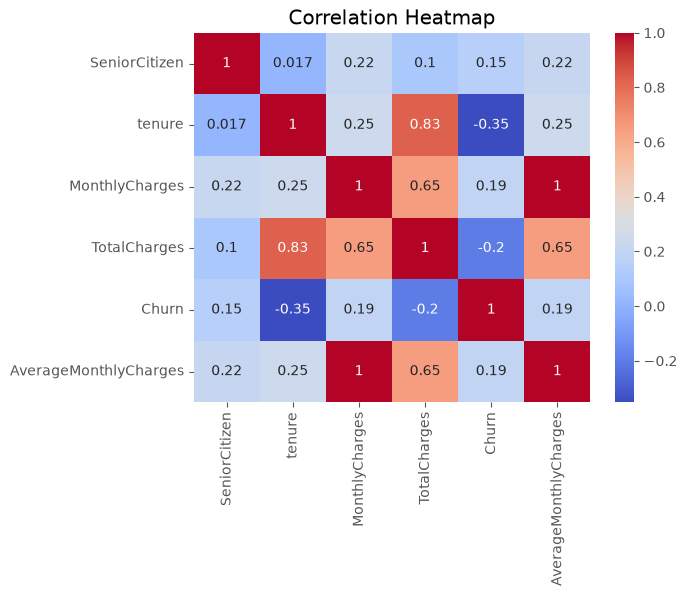

In [37]:

sns.heatmap(
    df.select_dtypes(include=["int64","float64"]).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Feature Engineering

Correlation heatmap shows that `MonthlyCharges` and `TotalCharges` move together, while `tenure` has a weaker relationship to billing values.

No extreme multicollinearity is present among the numeric features, which means the model can use them without major instability. The derived features may still add signal by capturing non-linear patterns and customer lifetime behavior.

`TenureGroup` created with four buckets.

Binned tenure simplifies relationships and helps visualize churn across tenure categories.

Derived `AverageMonthlyCharges` computed; division-by-zero handled.

Derived feature captures customer-level monthly spending and can improve model signal.

In [38]:
df[["tenure", "TotalCharges", "AverageMonthlyCharges"]].head()


,tenure,TotalCharges,AverageMonthlyCharges
0,1,29.85,29.850000
1,34,1889.50,55.573529
2,2,108.15,54.075000
3,45,1840.75,40.905556
4,2,151.65,75.825000


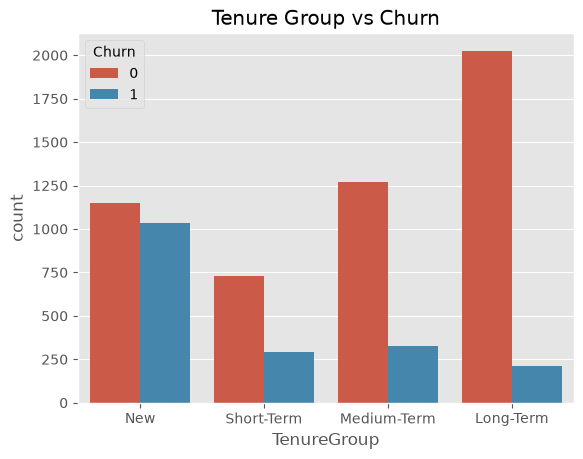

In [39]:
sns.countplot(
    data=df,
    x="TenureGroup",
    hue="Churn"
)

plt.title("Tenure Group vs Churn")

plt.show()

New customers have the highest churn rate, while churn decreases as tenure length increases. Long-term customers are much more likely to remain active, which confirms that customer lifecycle stage is an important signal for churn risk.

This pattern supports the business interpretation that newer customers may need stronger onboarding, engagement, and retention efforts to reduce early churn.

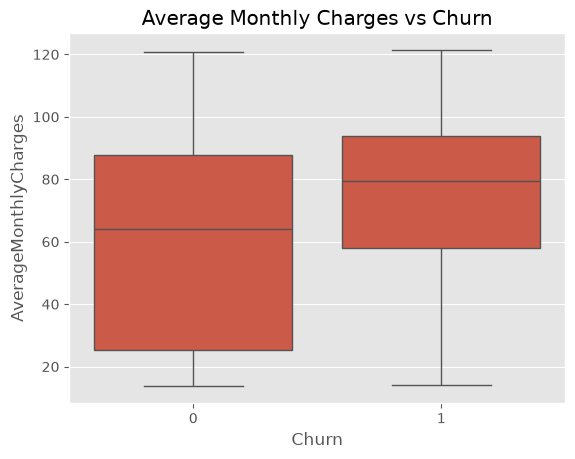

In [40]:
sns.boxplot(
    data=df,
    x="Churn",
    y="AverageMonthlyCharges"
)

plt.title("Average Monthly Charges vs Churn")

plt.show()

Average Monthly Charges: Customers who churned have a higher median average monthly charge than customers who stayed. The churned group also shows a broader spread in average monthly charges.

Business Insight: Customers with higher average monthly spend may be more price-sensitive or more likely to compare service value. This makes average monthly charges a useful signal for retention campaigns focused on high-value accounts.

### Identify numerical/categorical features


In [41]:
numerical_features = x_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = x_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)


Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AverageMonthlyCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']


/var/folders/p9/_62g3g211nl0rl1dvbxt61mh0000gn/T/ipykernel_46148/4152943172.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = x_train.select_dtypes(include=["object", "category"]).columns.tolist()


Lists of numerical and categorical feature names created from `x_train`.

Use these lists to build ColumnTransformer to avoid leakage.

### Preprocessing Pipeline

Identify numerical and categorical features from the training data only. Using `x_train` avoids data leakage when fitting preprocessing transformers.

In [42]:
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

Numeric pipeline defined for median imputation and scaling.

Ensures numeric features are imputed and standardized before modeling.

Build preprocessing pipelines: numeric pipeline imputes and scales; categorical pipeline imputes and one-hot-encodes. `ColumnTransformer` will apply them to appropriate columns.

In [43]:
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])

Categorical pipeline defined to impute with most frequent and one-hot encode.

One-hot encoding with `handle_unknown='ignore'` avoids errors for unseen categories in test data.

In [44]:


preprocessor = ColumnTransformer(

    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ])

`ColumnTransformer` created to apply pipelines to respective columns.

Centralizes preprocessing so it can be included inside model pipelines for safe cross-validation.

In [45]:


model_dtc =DecisionTreeClassifier(random_state=42, max_depth=5)

Define a baseline Decision Tree classifier with limited depth to reduce overfitting. The model will be wrapped in a pipeline with preprocessing.

In [46]:
model_1 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", model_dtc)
])

Baseline model pipeline assembled.

The pipeline ensures consistent preprocessing during training and inference.

In [47]:
model_1.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['gender','SeniorCitizen','Partner',...,'TotalCharges','TenureGroup', 'AverageMonthlyCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rem

Observation: Baseline Decision Tree pipeline trained on the training set (preprocessing + classifier).

Finding: Model is ready for prediction; proceed to evaluate on test set to measure generalization.

Train the baseline pipeline (`preprocessor` + classifier) on the training set. This fits both preprocessing steps and the model without leaking test data.

In [48]:
model_dtc_2 = DecisionTreeClassifier(random_state=42, max_depth=8, min_samples_split=10, min_samples_leaf=5)

In [49]:
model_2 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", model_dtc_2)
])

In [50]:
model_2.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['gender','SeniorCitizen','Partner',...,'TotalCharges','TenureGroup', 'AverageMonthlyCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rem

Observation: Second Decision Tree pipeline trained with different hyperparameters.

Finding: Compare both models using standardized metrics to choose the better configuration.

In [51]:
y_pred_1 = model_1.predict(x_test)
print(y_pred_1)

[1 0 1 ... 0 0 0]


Observation: Predictions array printed for `model_1` — binary labels for test samples.

Finding: Use evaluation metrics to summarize predictive performance rather than raw prediction arrays.

In [52]:
y_pred_2 = model_2.predict(x_test)
print(y_pred_2)

[0 0 1 ... 0 0 0]


Observation: Predictions array printed for `model_2`.

Finding: Compare metrics between `model_1` and `model_2` to evaluate impact of hyperparameters.

In [53]:
def evaluate_model(model, x_test, y_test):

    predictions = model.predict(x_test)

    return {
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions),
        "recall": recall_score(y_test, predictions),
        "f1_score": f1_score(y_test, predictions),
        "confusion_matrix": confusion_matrix(y_test, predictions)
    }

Evaluation helper returns common classification metrics. Use `f1` when classes are imbalanced because it balances precision and recall.

In [54]:
results_model_1 = evaluate_model(model_1, x_test, y_test)
results_model_2 = evaluate_model(model_2, x_test, y_test)


In [55]:
comparison_df = pd.DataFrame([results_model_1, results_model_2], index=["Model 1", "Model 2"])
comparison_df

,accuracy,precision,recall,f1_score,confusion_matrix
Model 1,0.793658,0.613843,0.600713,0.607207,"[[1340, 212], [224, 337]]"
Model 2,0.778514,0.591356,0.536542,0.562617,"[[1344, 208], [260, 301]]"


Comparison table shows that Model 1 performs better than Model 2 on the relevant metrics, especially F1 score and recall. This indicates that the simpler tree configuration better captures meaningful churn patterns in the dataset without over-regularizing.

Model 1 is therefore selected as the stronger baseline for further tuning and comparison against alternative approaches.

In [56]:
catboost_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    random_seed=42,
    verbose=0
)


In [57]:

catboost_model.fit(
    x_train,
    y_train,
    cat_features=categorical_features
)


CatBoostClassifier(depth=6, iterations=500, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=0)


CatBoost training completed successfully using the categorical feature list.

In [58]:
y_pred_3 = catboost_model.predict(x_test)
print(y_pred_3)


[1 0 1 ... 0 1 0]


In [59]:
results_model_3 = evaluate_model(catboost_model, x_test, y_test)


In [60]:
comparison_df = pd.DataFrame([results_model_1, results_model_2, results_model_3], index=["Model 1", "Model 2", "Model 3"])
comparison_df

,accuracy,precision,recall,f1_score,confusion_matrix
Model 1,0.793658,0.613843,0.600713,0.607207,"[[1340, 212], [224, 337]]"
Model 2,0.778514,0.591356,0.536542,0.562617,"[[1344, 208], [260, 301]]"
Model 3,0.795551,0.651054,0.495544,0.562753,"[[1403, 149], [283, 278]]"


Compare CatBoost with the two Decision Tree configurations using accuracy, precision, recall, and F1 score.

For a churn-retention problem, recall is especially important because failing to identify a customer who is likely to leave can translate into lost revenue and missed retention opportunities. Business priorities should therefore be considered alongside raw accuracy when choosing the final model.

The final selection should balance predictive usefulness with the operational cost of false alarms and missed churners.

In [61]:
param_grid = {
    "classifier__max_depth": [3, 4, 5, 6, 7, 8, 10],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 5, 10],
    "classifier__criterion": ["gini", "entropy"],
    "classifier__class_weight": [None, "balanced"]
}

In [62]:
dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

In [63]:
grid_search = GridSearchCV(
    dt_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [64]:
grid_search.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__class_weight': [None, 'balanced'], 'classifier__criterion': ['gini', 'entropy'], 'classifier__max_depth': [3, 4, ...], 'classifier__min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versi

In [65]:
grid_search.best_params_

{'classifier__class_weight': 'balanced',
 'classifier__criterion': 'entropy',
 'classifier__max_depth': 4,
 'classifier__min_samples_leaf': 1,
 'classifier__min_samples_split': 2}

Observation: Grid search selected a configuration with class weighting and a moderate tree depth, suggesting that balancing the minority class improves churn detection.

Finding: Class weighting helps the model pay more attention to churners, which is essential in an imbalanced classification setting where missing churn candidates can be costly.

In [66]:
tuned_model_1 = grid_search.best_estimator_

tuned_model_1_results = evaluate_model(
    tuned_model_1,
    x_test,
    y_test
)

tuned_model_1_results

{'accuracy': 0.7486985328916232,
 'precision': 0.5182926829268293,
 'recall': 0.7575757575757576,
 'f1_score': 0.6154960173787111,
 'confusion_matrix': array([[1157,  395],
        [ 136,  425]])}

Tuned model evaluation: accuracy ≈ 0.7487, precision ≈ 0.5183, recall ≈ 0.7576, F1 ≈ 0.6155.

This tuning substantially improves recall, reducing the number of missed churners. In a churn prediction setting, this is valuable because identifying more at-risk customers enables proactive retention actions even if a few non-churners are flagged as well.

In [67]:
comparison_df = pd.DataFrame([tuned_model_1_results,results_model_1, results_model_2, results_model_3], index=["Tuned Model 1","Model 1", "Model 2", "Model 3"])
comparison_df

,accuracy,precision,recall,f1_score,confusion_matrix
Tuned Model 1,0.748699,0.518293,0.757576,0.615496,"[[1157, 395], [136, 425]]"
Model 1,0.793658,0.613843,0.600713,0.607207,"[[1340, 212], [224, 337]]"
Model 2,0.778514,0.591356,0.536542,0.562617,"[[1344, 208], [260, 301]]"
Model 3,0.795551,0.651054,0.495544,0.562753,"[[1403, 149], [283, 278]]"


Tuned Model 1 is selected because it provides the best recall (approximately 75.76%), the lowest false negatives, and the strongest F1 score among the tested models. For a telecom churn prediction task, this is a practical business advantage because the company can identify a large proportion of customers at risk of leaving and intervene before those customers actually churn.

The trade-off is a higher number of false positives, which means some retention efforts will be directed toward customers who might have stayed anyway. However, in customer retention scenarios, this trade-off is often acceptable when the cost of missing a churner is greater than the cost of sending a proactive retention offer.

In [68]:
final_model = tuned_model_1

In [69]:
y_pred = final_model.predict(x_test)

In [70]:
from sklearn.metrics import classification_report


print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.75      0.81      1552
           1       0.52      0.76      0.62       561

    accuracy                           0.75      2113
   macro avg       0.71      0.75      0.71      2113
weighted avg       0.79      0.75      0.76      2113



Classification report prints precision, recall, and F1 for each class. The tuned model performs better on the churn class than a purely accuracy-focused model would suggest, which is important because the churn class is the business-relevant target.

The report supports the choice of a recall-oriented model, especially when the objective is to minimize missed churners while still maintaining a workable precision level.

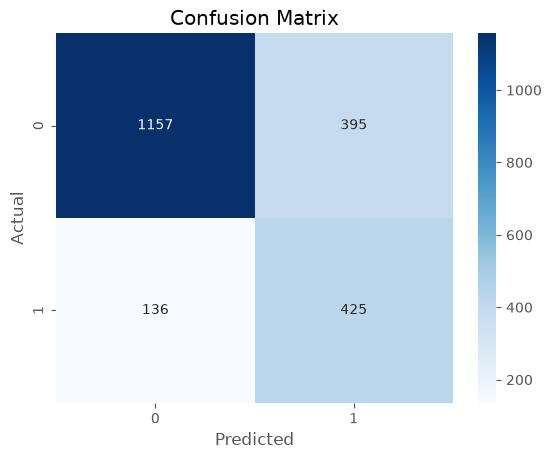

In [71]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Recall should generally receive higher priority than precision in a churn-retention setting, although precision must remain reasonable to avoid wasting retention resources. The tuned model is suitable for telecom churn prediction because it is able to identify a large portion of actual churners while keeping false negatives relatively low.

The main trade-off is the number of false positives, which means the business may target some customers who would have stayed anyway. However, this is often acceptable when the goal is early intervention and retention of vulnerable customers, especially when the cost of losing a customer is high.

In [72]:
tree_model = final_model.named_steps["classifier"]

In [73]:
preprocessor_fitted = final_model.named_steps["preprocessor"]

In [74]:
feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

In [75]:
importance = tree_model.feature_importances_

In [76]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

Feature importance DataFrame created; the strongest contributors include contract type, tenure, internet service, and monthly charges.

This pattern aligns with the exploratory findings: customers with short tenure, month-to-month contracts, and higher monthly costs are more likely to churn. These variables provide actionable signals for retention planning.

In [77]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [78]:
feature_importance.head(15)

,Feature,Importance
37,cat__Contract_Month-to-month,0.601311
1,num__tenure,0.130961
17,cat__InternetService_Fiber optic,0.105544
2,num__MonthlyCharges,0.054402
19,cat__OnlineSecurity_No,0.038810
32,cat__StreamingTV_No internet service,0.016802
28,cat__TechSupport_No,0.015819
3,num__TotalCharges,0.012316
44,cat__PaymentMethod_Electronic check,0.011355
38,cat__Contract_One year,0.008484


#### Ploting the feature improtance

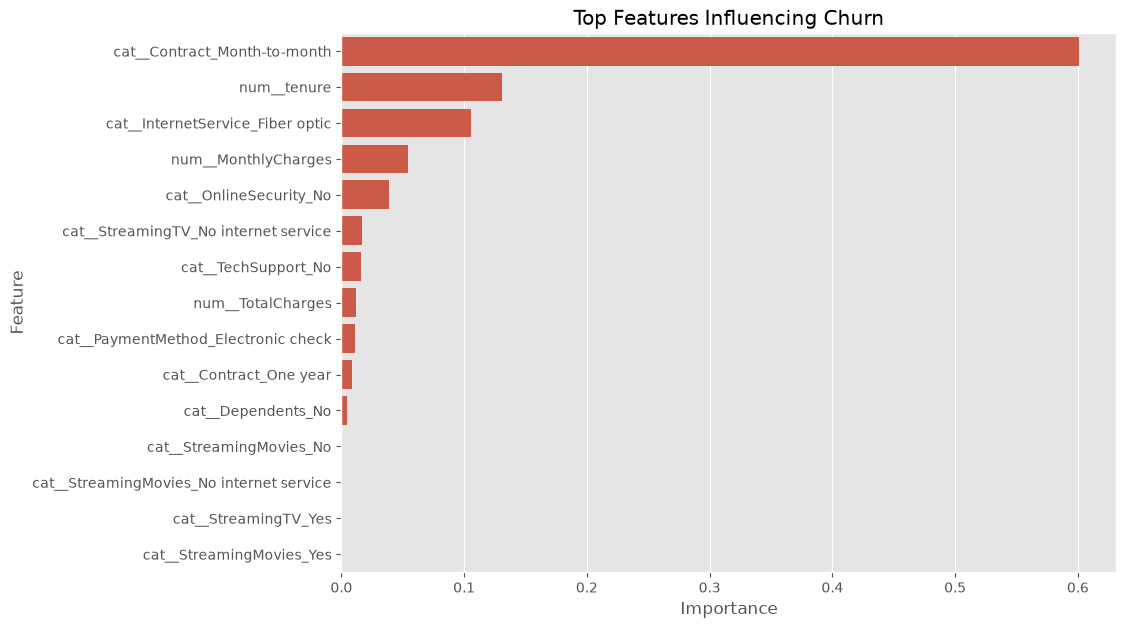

In [79]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top Features Influencing Churn")

plt.show()

#### Plotting the feature importance

The bar chart ranks the variables by how much they contribute to the final decision tree. This is a useful way to summarize which factors matter most for churn prediction and helps translate model output into business actions.

The top features highlight the importance of contractual commitment and customer lifecycle stage, reinforcing earlier EDA findings.


### Saving the model and preprocessing pipeline

In [80]:
import joblib


joblib.dump(
    final_model,
    "../model/churn_model.pkl"
)

['../model/churn_model.pkl']

Final tuned model save to `../model/churn_model.pkl`.


In [81]:
joblib.dump(
    preprocessor_fitted,
    "../model/preprocessing_pipeline.pkl"
)

['../model/preprocessing_pipeline.pkl']

### Showing the Decision tree

In [82]:
tree_model = final_model.named_steps["classifier"]

preprocessor = final_model.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

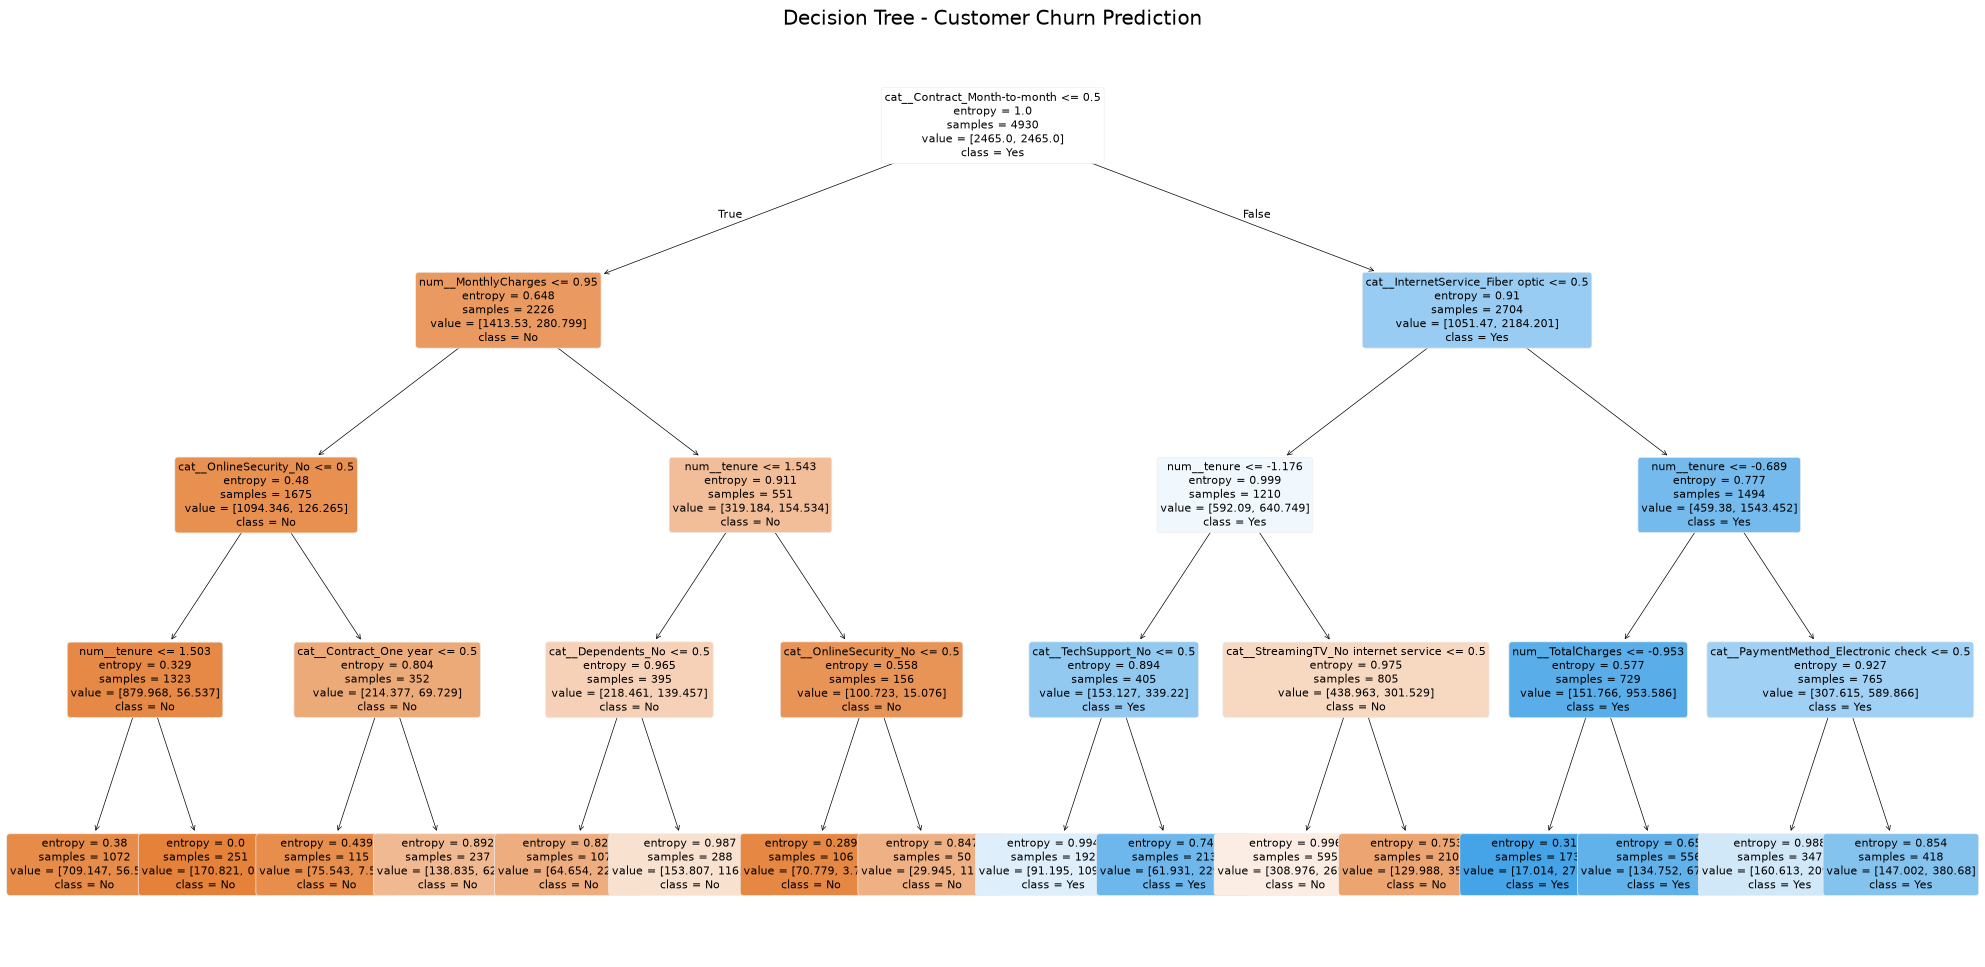

In [83]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 12))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree - Customer Churn Prediction")
plt.show()

#### Decision Tree Interpretation

The decision tree indicates that **contract type** is one of the key factors associated with customer churn. Customers on **month-to-month contracts** are more frequently directed toward branches associated with churn. Other features, including **internet service, monthly charges, and tenure**, also contribute to subsequent decision points in the tree.

The model suggests that customers with **shorter tenure, month-to-month contracts, and higher monthly charges** are associated with a higher likelihood of churn. From a business perspective, these customer segments could be considered for **targeted retention strategies**, such as personalized offers, contract incentives, or enhanced customer support.

It is important to note that these relationships represent **patterns identified by the model and do not necessarily imply that these factors directly cause customer churn**.
